In [1]:
# ── Cell 1: Imports & Load Data ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50)

df = pd.read_csv("datasets/Student Attitude and Behavior.csv")

# Standardise column names
df.columns = df.columns.str.strip()

print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (235, 19)


,Certification Course,Gender,Department,Height(CM),Weight(KG),10th Mark,12th Mark,college mark,hobbies,daily studing time,prefer to study in,salary expectation,Do you like your degree?,willingness to pursue a career based on their degree,social medai & video,Travelling Time,Stress Level,Financial Status,part-time job
0,No,Male,BCA,100.0,58.0,79.0,64.0,80.0,Video Games,0 - 30 minute,Morning,40000,No,50%,1.30 - 2 hour,30 - 60 minutes,Bad,Bad,No
1,No,Female,BCA,90.0,40.0,70.0,80.0,70.0,Cinema,30 - 60 minute,Morning,15000,Yes,75%,1 - 1.30 hour,0 - 30 minutes,Bad,Bad,No
2,Yes,Male,BCA,159.0,78.0,71.0,61.0,55.0,Cinema,1 - 2 Hour,Anytime,13000,Yes,50%,More than 2 hour,30 - 60 minutes,Awful,Bad,No
3,Yes,Female,BCA,147.0,20.0,70.0,59.0,58.0,Reading books,1 - 2 Hour,Anytime,1500000,No,50%,1.30 - 2 hour,0 - 30 minutes,Bad,good,No
4,No,Male,BCA,170.0,54.0,40.0,65.0,30.0,Video Games,30 - 60 minute,Morning,50000,Yes,25%,1.30 - 2 hour,30 - 60 minutes,Good,good,No


In [2]:
# ── Cell 2: Schema & Basic Statistics ────────────────────────────────────────
print("Shape:", df.shape)
print("\nDtypes:")
display(df.dtypes.to_frame("dtype"))
print("\nDescriptive Stats (numeric):")
display(df.describe().round(2))
print("\nDescriptive Stats (categorical):")
display(df.describe(include="object"))

Shape: (235, 19)

Dtypes:


,dtype
Certification Course,object
Gender,object
Department,object
Height(CM),float64
Weight(KG),float64
10th Mark,float64
12th Mark,float64
college mark,float64
hobbies,object
daily studing time,object



Descriptive Stats (numeric):


,Height(CM),Weight(KG),10th Mark,12th Mark,college mark,salary expectation
count,235.00,235.0,235.00,235.00,235.00,235.00
mean,157.40,60.8,76.85,68.78,70.66,32481.68
std,21.51,14.9,13.05,11.02,15.73,111314.63
min,4.50,20.0,7.40,45.00,1.00,0.00
25%,152.00,50.0,70.00,60.00,60.00,15000.00
50%,160.00,60.0,80.00,69.00,70.00,20000.00
75%,170.00,70.0,86.25,76.00,80.00,25000.00
max,192.00,106.0,98.00,94.00,100.00,1500000.00



Descriptive Stats (categorical):


,Certification Course,Gender,Department,hobbies,daily studing time,prefer to study in,Do you like your degree?,willingness to pursue a career based on their degree,social medai & video,Travelling Time,Stress Level,Financial Status,part-time job
count,235,235,235,235,235,235,235,235,235,235,235,235,235
unique,2,2,4,4,6,3,2,5,6,7,4,4,2
top,Yes,Male,BCA,Sports,30 - 60 minute,Anytime,Yes,75%,30 - 60 Minute,30 - 60 minutes,Good,good,No
freq,152,156,132,85,81,111,215,114,69,80,137,129,194


In [3]:
# ── Cell 3: Data Quality Audit ───────────────────────────────────────────────
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct,
    "n_unique": df.nunique(dropna=False),
    "dtype": df.dtypes
})
print("Duplicate rows:", df.duplicated().sum())
print("\nQuality Report:")
display(quality)

# Plot missing values
if missing_pct.sum() > 0:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_pct.index, y=missing_pct.values, palette="flare")
    plt.title("Missing Values (%) per Column")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing %")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing values found.")

Duplicate rows: 0

Quality Report:


,missing_count,missing_pct,n_unique,dtype
10th Mark,0,0.0,67,float64
12th Mark,0,0.0,67,float64
Certification Course,0,0.0,2,object
Department,0,0.0,4,object
Do you like your degree?,0,0.0,2,object
Financial Status,0,0.0,4,object
Gender,0,0.0,2,object
Height(CM),0,0.0,56,float64
Stress Level,0,0.0,4,object
Travelling Time,0,0.0,7,object



No missing values found.


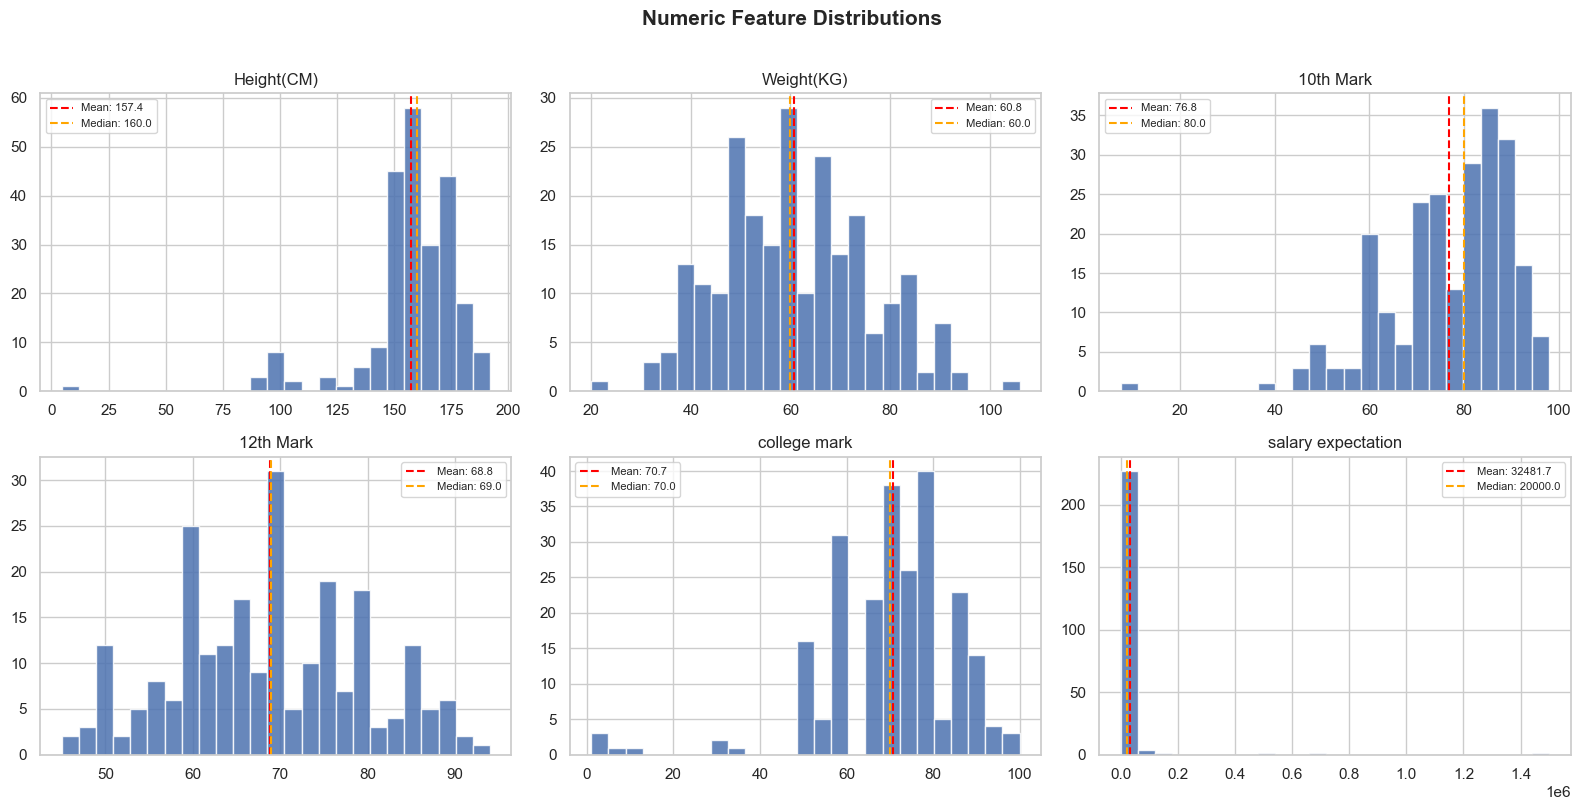

In [4]:
# ── Cell 4: Numeric Univariate – Distributions ───────────────────────────────
numeric_cols = ["Height(CM)", "Weight(KG)", "10th Mark", "12th Mark", "college mark", "salary expectation"]
numeric_cols = [c for c in numeric_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = pd.to_numeric(df[col], errors="coerce").dropna()
    axes[i].hist(data, bins=25, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[i].axvline(data.mean(), color="red", linestyle="--", label=f"Mean: {data.mean():.1f}")
    axes[i].axvline(data.median(), color="orange", linestyle="--", label=f"Median: {data.median():.1f}")
    axes[i].set_title(f"{col}", fontsize=12)
    axes[i].legend(fontsize=8)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Numeric Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

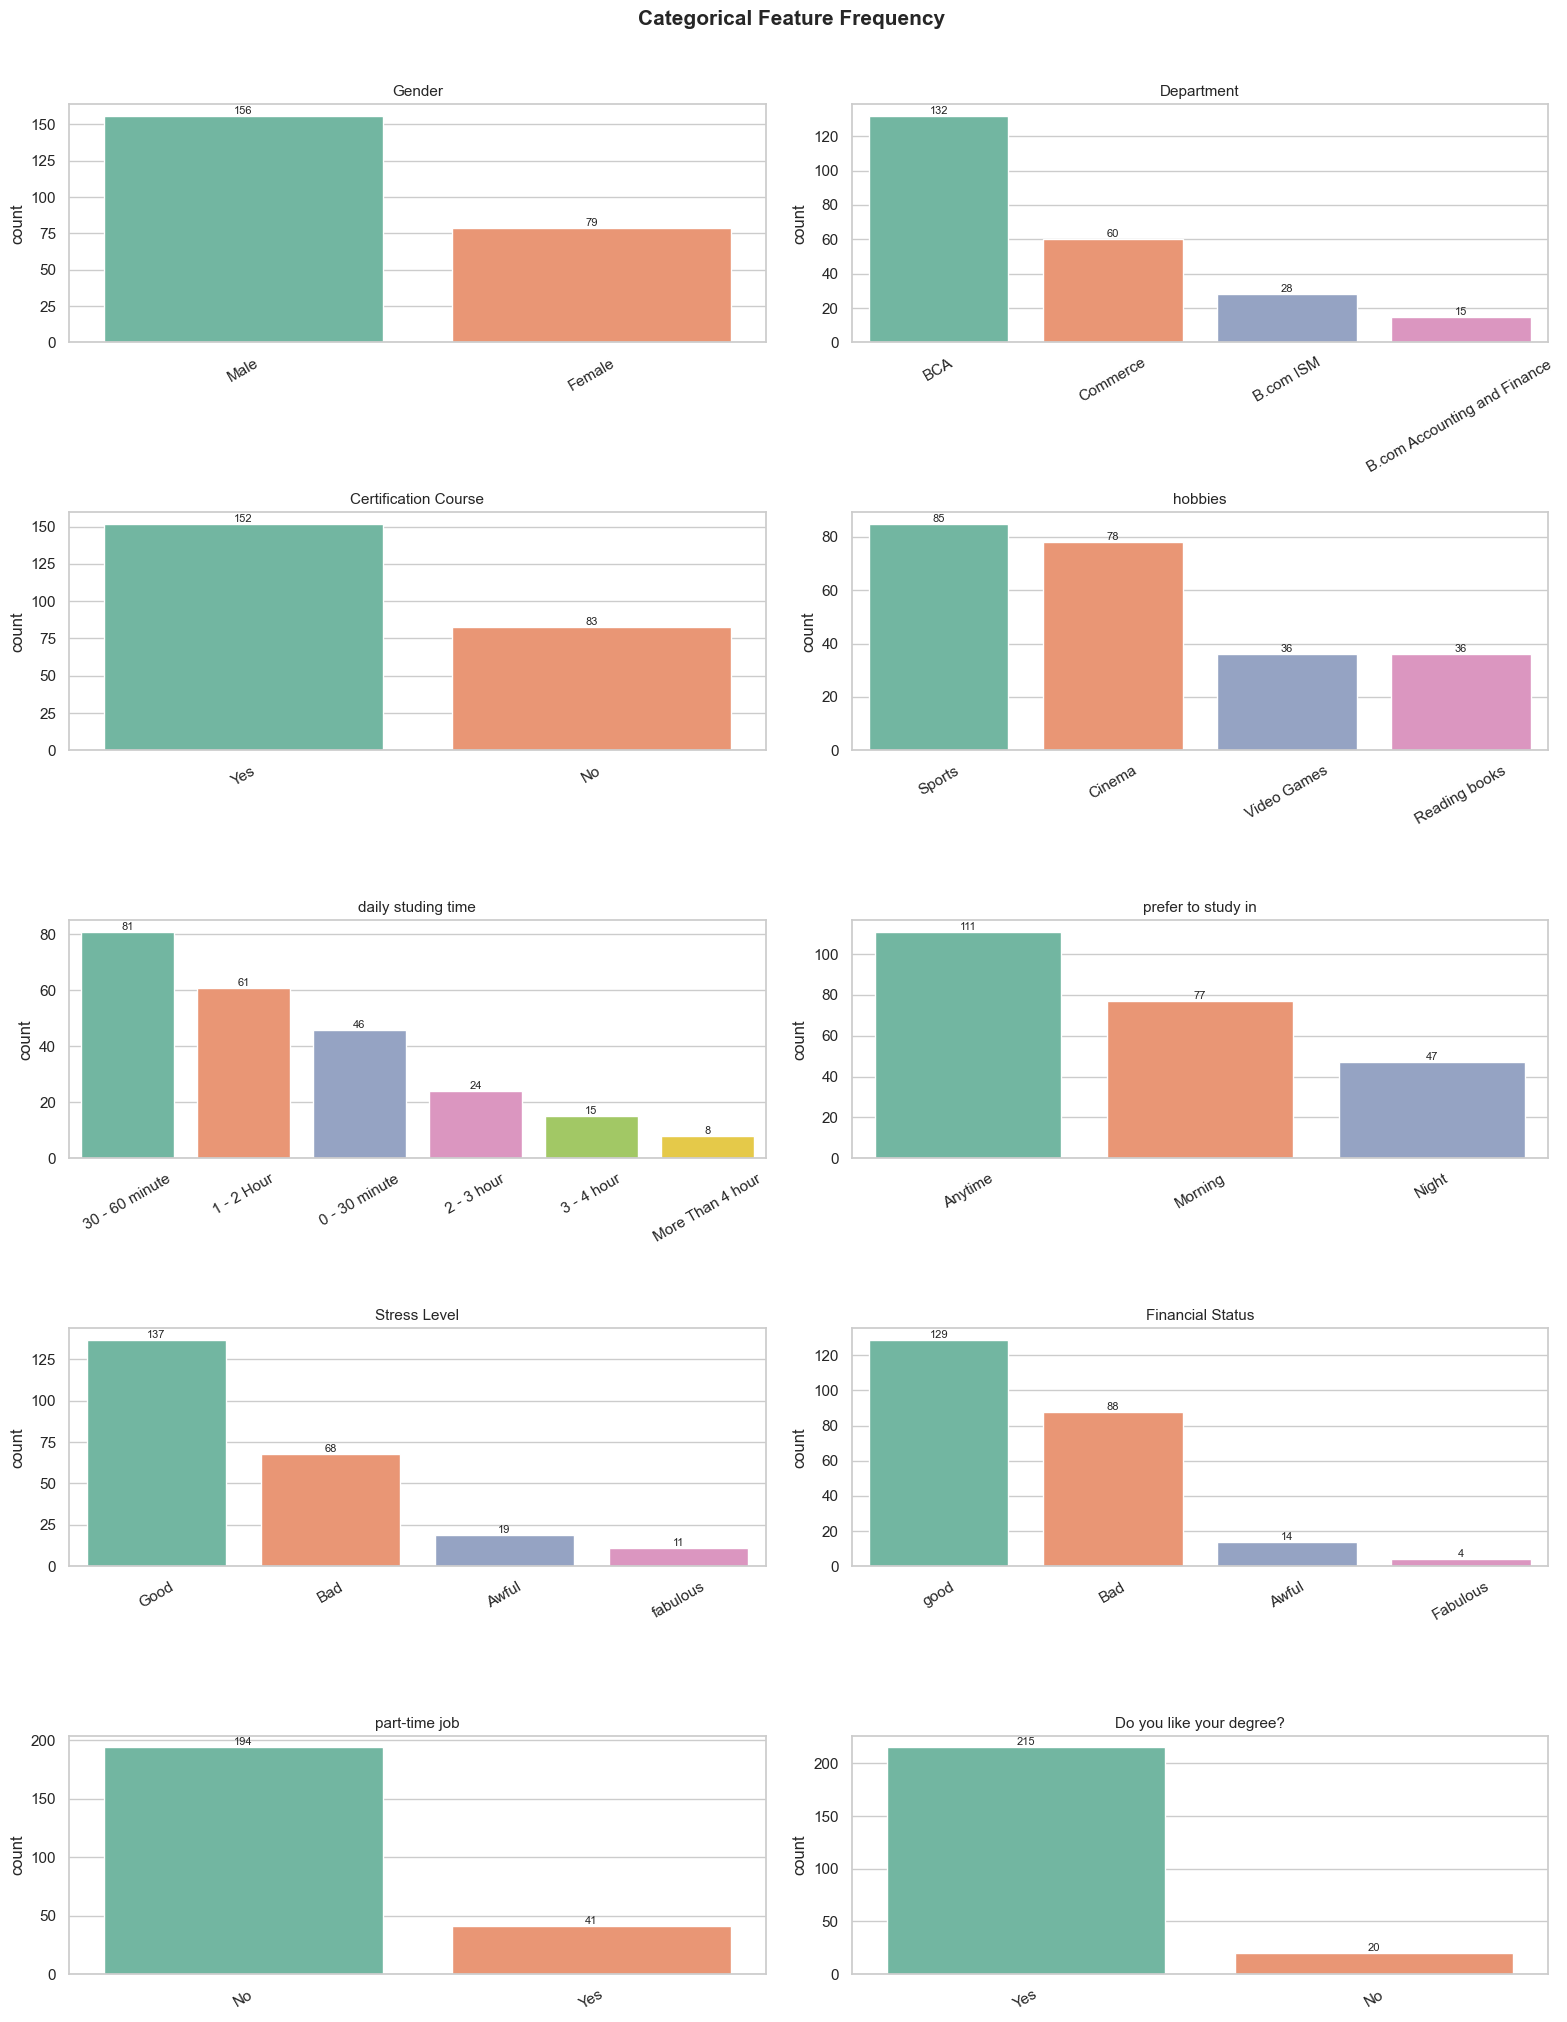

In [5]:
# ── Cell 5: Categorical Univariate – Frequency Charts ────────────────────────
cat_cols = ["Gender", "Department", "Certification Course", "hobbies",
            "daily studing time", "prefer to study in", "Stress Level",
            "Financial Status", "part-time job", "Do you like your degree?"]
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(int(np.ceil(len(cat_cols) / 2)), 2, figsize=(16, 4 * int(np.ceil(len(cat_cols) / 2))))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].astype(str).value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col}", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())}",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha="center", va="bottom", fontsize=8)

for j in range(len(cat_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Categorical Feature Frequency", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

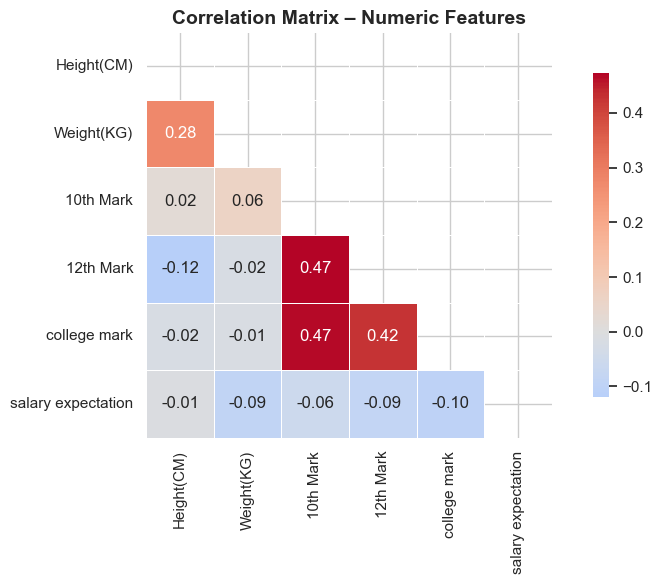


Top 6 absolute correlations:


,Feature A,Feature B,Correlation
0,10th Mark,12th Mark,0.473254
1,10th Mark,college mark,0.465861
2,12th Mark,college mark,0.424828
3,Height(CM),Weight(KG),0.275948
4,Height(CM),12th Mark,-0.119618
5,college mark,salary expectation,-0.103034


In [6]:
# ── Cell 6: Correlation Heatmap (Numeric Features) ───────────────────────────
num_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(9, 6))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix – Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Top correlated pairs
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
              .stack().reset_index())
pairs.columns = ["Feature A", "Feature B", "Correlation"]
pairs["Abs"] = pairs["Correlation"].abs()
print("\nTop 6 absolute correlations:")
display(pairs.sort_values("Abs", ascending=False).head(6).drop(columns="Abs").reset_index(drop=True))

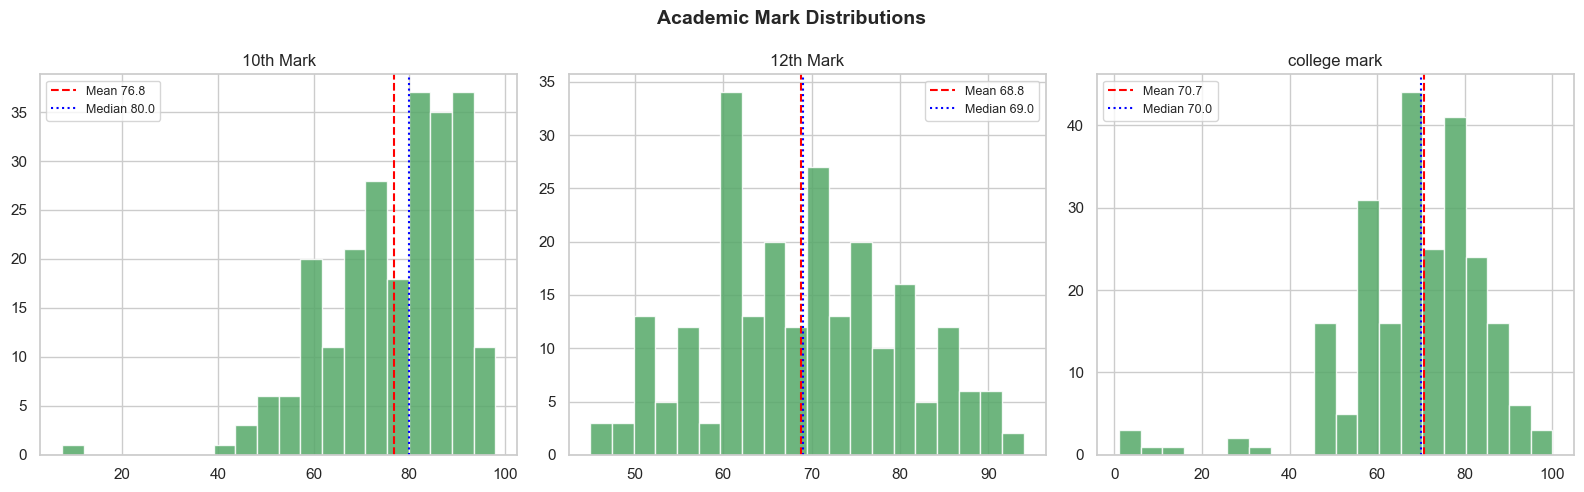

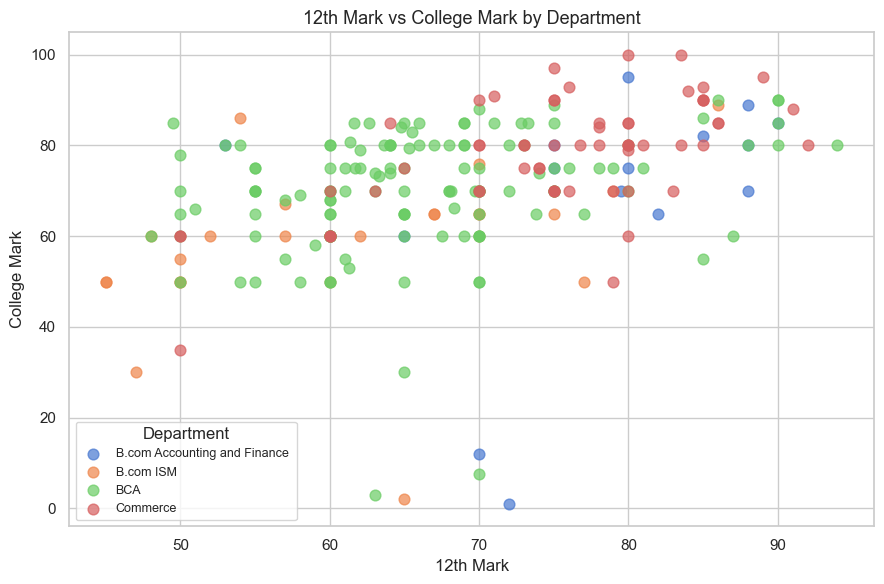

In [7]:
# ── Cell 7: Academic Performance – 10th vs 12th vs College Mark ──────────────
marks_df = df[["10th Mark", "12th Mark", "college mark"]].apply(pd.to_numeric, errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["10th Mark", "12th Mark", "college mark"]):
    data = marks_df[col].dropna()
    ax.hist(data, bins=20, color="#55A868", edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(), color="red",    linestyle="--", label=f"Mean {data.mean():.1f}")
    ax.axvline(data.median(), color="blue", linestyle=":",  label=f"Median {data.median():.1f}")
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle("Academic Mark Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Scatter: 12th Mark vs College Mark coloured by Department
plt.figure(figsize=(9, 6))
for dept, grp in df.groupby("Department"):
    x = pd.to_numeric(grp["12th Mark"], errors="coerce")
    y = pd.to_numeric(grp["college mark"], errors="coerce")
    plt.scatter(x, y, label=dept, alpha=0.7, s=60)

plt.xlabel("12th Mark")
plt.ylabel("College Mark")
plt.title("12th Mark vs College Mark by Department", fontsize=13)
plt.legend(title="Department", fontsize=9)
plt.tight_layout()
plt.show()

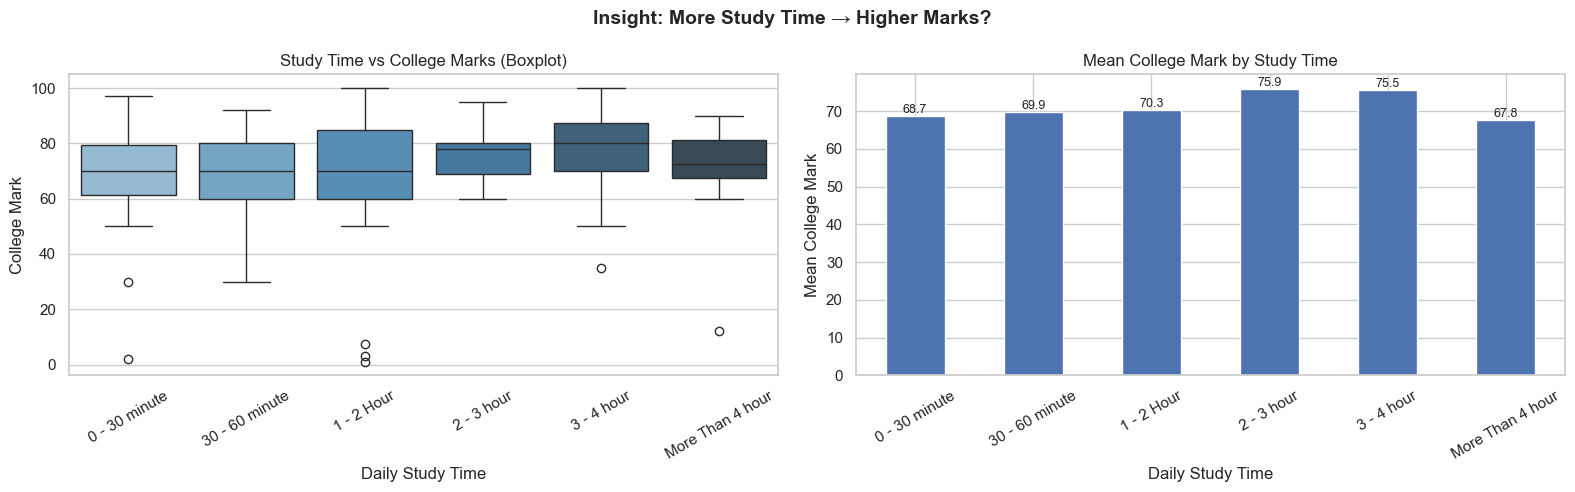

In [8]:
# ── Cell 8: Daily Study Time vs College Marks ────────────────────────────────
study_order = ["0 - 30 minute", "30 - 60 minute", "1 - 2 Hour",
               "2 - 3 hour", "3 - 4 hour", "More Than 4 hour"]
study_order = [s for s in study_order if s in df["daily studing time"].values]

df["college mark_num"] = pd.to_numeric(df["college mark"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box plot
sns.boxplot(data=df, x="daily studing time", y="college mark_num",
            order=study_order, palette="Blues_d", ax=axes[0])
axes[0].set_title("Study Time vs College Marks (Boxplot)", fontsize=12)
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_xlabel("Daily Study Time")
axes[0].set_ylabel("College Mark")

# Mean bar chart
avg = (df.groupby("daily studing time")["college mark_num"]
         .mean()
         .reindex(study_order))
avg.plot(kind="bar", color="#4C72B0", edgecolor="white", ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)
axes[1].set_title("Mean College Mark by Study Time", fontsize=12)
axes[1].set_xlabel("Daily Study Time")
axes[1].set_ylabel("Mean College Mark")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Insight: More Study Time → Higher Marks?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

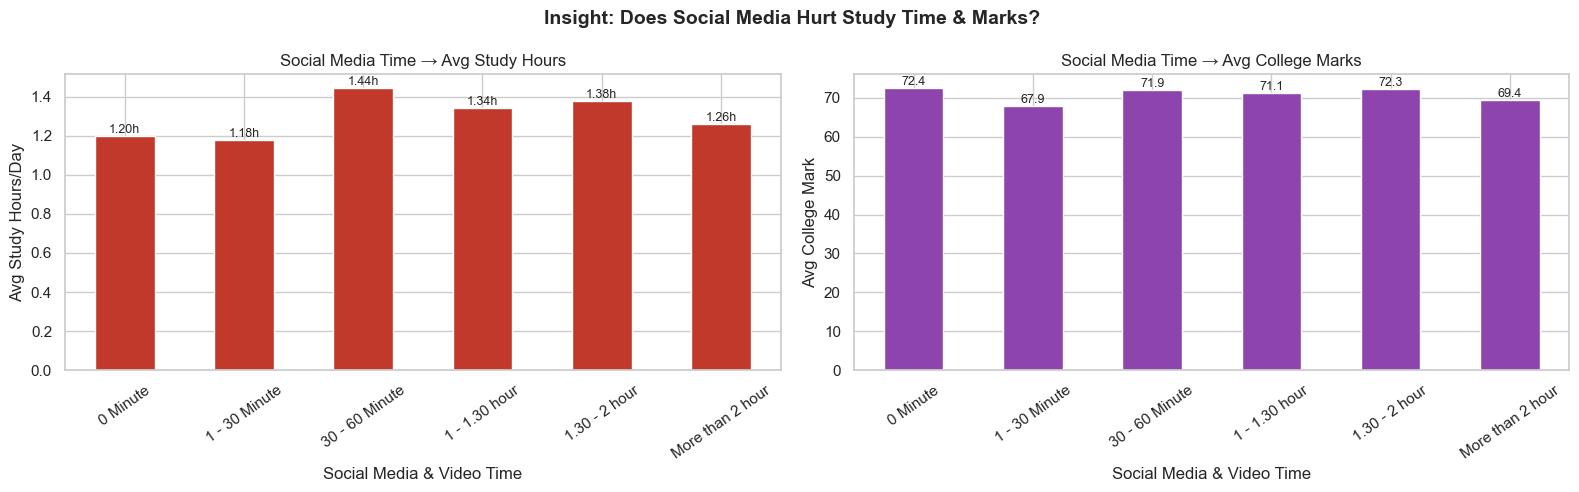

In [9]:
# ── Cell 9: Social Media Time vs Study Time & Marks ──────────────────────────
sm_order = ["0 Minute", "1 - 30 Minute", "30 - 60 Minute",
            "1 - 1.30 hour", "1.30 - 2 hour", "More than 2 hour"]
sm_col = "social medai & video"
sm_order = [s for s in sm_order if s in df[sm_col].values]

study_time_map = {
    "0 - 30 minute": 0.25, "30 - 60 minute": 0.75,
    "1 - 2 Hour": 1.5, "2 - 3 hour": 2.5,
    "3 - 4 hour": 3.5, "More Than 4 hour": 4.5
}
df["study_hours_num"] = df["daily studing time"].map(study_time_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Social media vs study hours
avg_study = df.groupby(sm_col)["study_hours_num"].mean().reindex(sm_order)
avg_study.plot(kind="bar", color="#c0392b", edgecolor="white", ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}h",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)
axes[0].set_title("Social Media Time → Avg Study Hours", fontsize=12)
axes[0].set_xlabel("Social Media & Video Time")
axes[0].set_ylabel("Avg Study Hours/Day")
axes[0].tick_params(axis="x", rotation=35)

# Social media vs college marks
avg_marks = df.groupby(sm_col)["college mark_num"].mean().reindex(sm_order)
avg_marks.plot(kind="bar", color="#8e44ad", edgecolor="white", ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)
axes[1].set_title("Social Media Time → Avg College Marks", fontsize=12)
axes[1].set_xlabel("Social Media & Video Time")
axes[1].set_ylabel("Avg College Mark")
axes[1].tick_params(axis="x", rotation=35)

plt.suptitle("Insight: Does Social Media Hurt Study Time & Marks?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

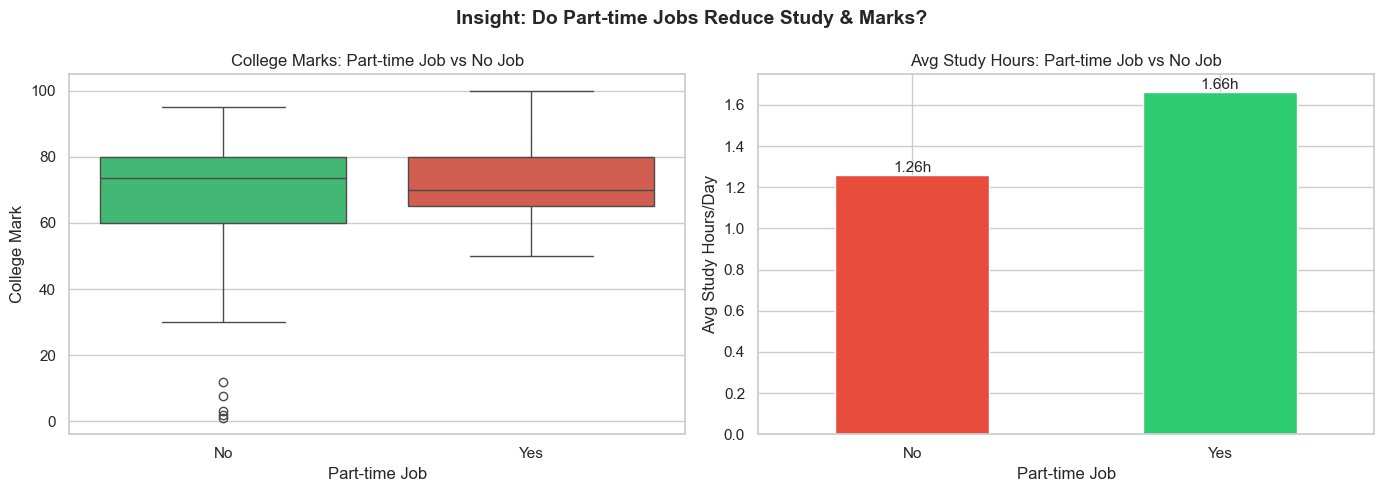


Mean college marks by part-time job:


,mean,median,count
part-time job,,,
No,70.35,73.65,194
Yes,72.12,70.00,41


In [10]:
# ── Cell 10: Part-Time Job Impact on Marks & Study Time ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# College marks by part-time job
sns.boxplot(data=df, x="part-time job", y="college mark_num",
            palette={"Yes": "#e74c3c", "No": "#2ecc71"}, ax=axes[0])
axes[0].set_title("College Marks: Part-time Job vs No Job", fontsize=12)
axes[0].set_xlabel("Part-time Job")
axes[0].set_ylabel("College Mark")

# Study time by part-time job
avg_st = df.groupby("part-time job")["study_hours_num"].mean()
avg_st.plot(kind="bar", color=["#e74c3c", "#2ecc71"], edgecolor="white",
            ax=axes[1], legend=False)
axes[1].set_title("Avg Study Hours: Part-time Job vs No Job", fontsize=12)
axes[1].set_xlabel("Part-time Job")
axes[1].set_ylabel("Avg Study Hours/Day")
axes[1].tick_params(axis="x", rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}h",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=11)

plt.suptitle("Insight: Do Part-time Jobs Reduce Study & Marks?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nMean college marks by part-time job:")
display(df.groupby("part-time job")["college mark_num"].agg(["mean","median","count"]).round(2))

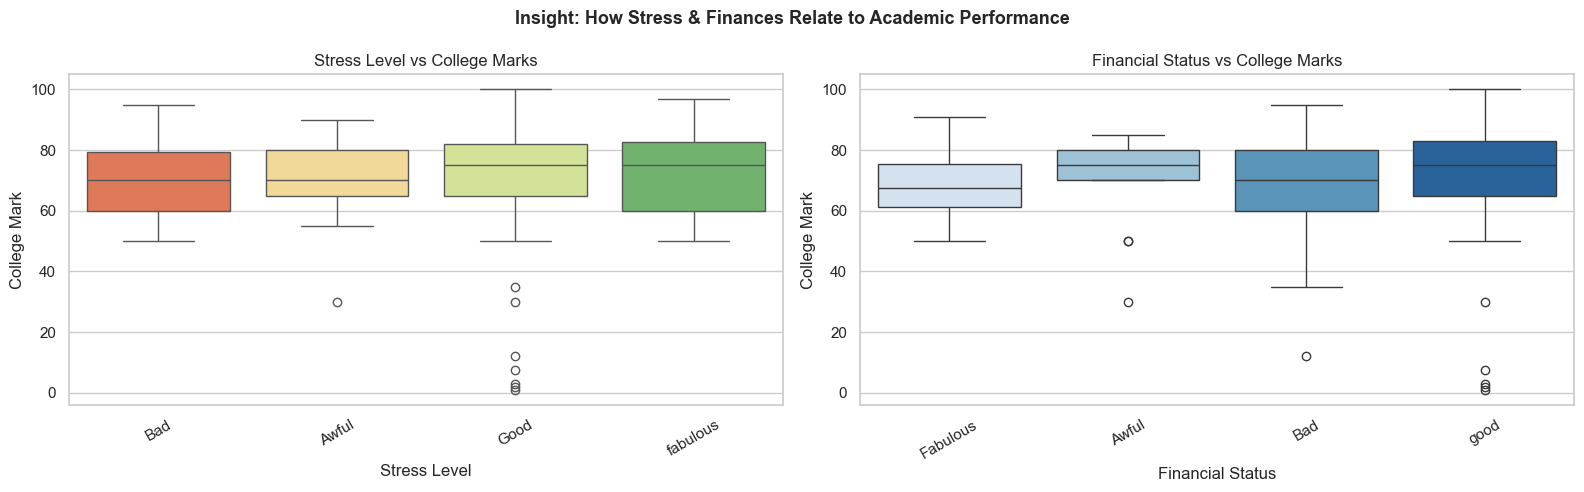

In [11]:
# ── Cell 11: Stress Level & Financial Status vs College Marks ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

stress_order = df.groupby("Stress Level")["college mark_num"].mean().sort_values().index.tolist()
sns.boxplot(data=df, x="Stress Level", y="college mark_num",
            order=stress_order, palette="RdYlGn", ax=axes[0])
axes[0].set_title("Stress Level vs College Marks", fontsize=12)
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_xlabel("Stress Level")
axes[0].set_ylabel("College Mark")

fin_order = df.groupby("Financial Status")["college mark_num"].mean().sort_values().index.tolist()
sns.boxplot(data=df, x="Financial Status", y="college mark_num",
            order=fin_order, palette="Blues", ax=axes[1])
axes[1].set_title("Financial Status vs College Marks", fontsize=12)
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_xlabel("Financial Status")
axes[1].set_ylabel("College Mark")

plt.suptitle("Insight: How Stress & Finances Relate to Academic Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

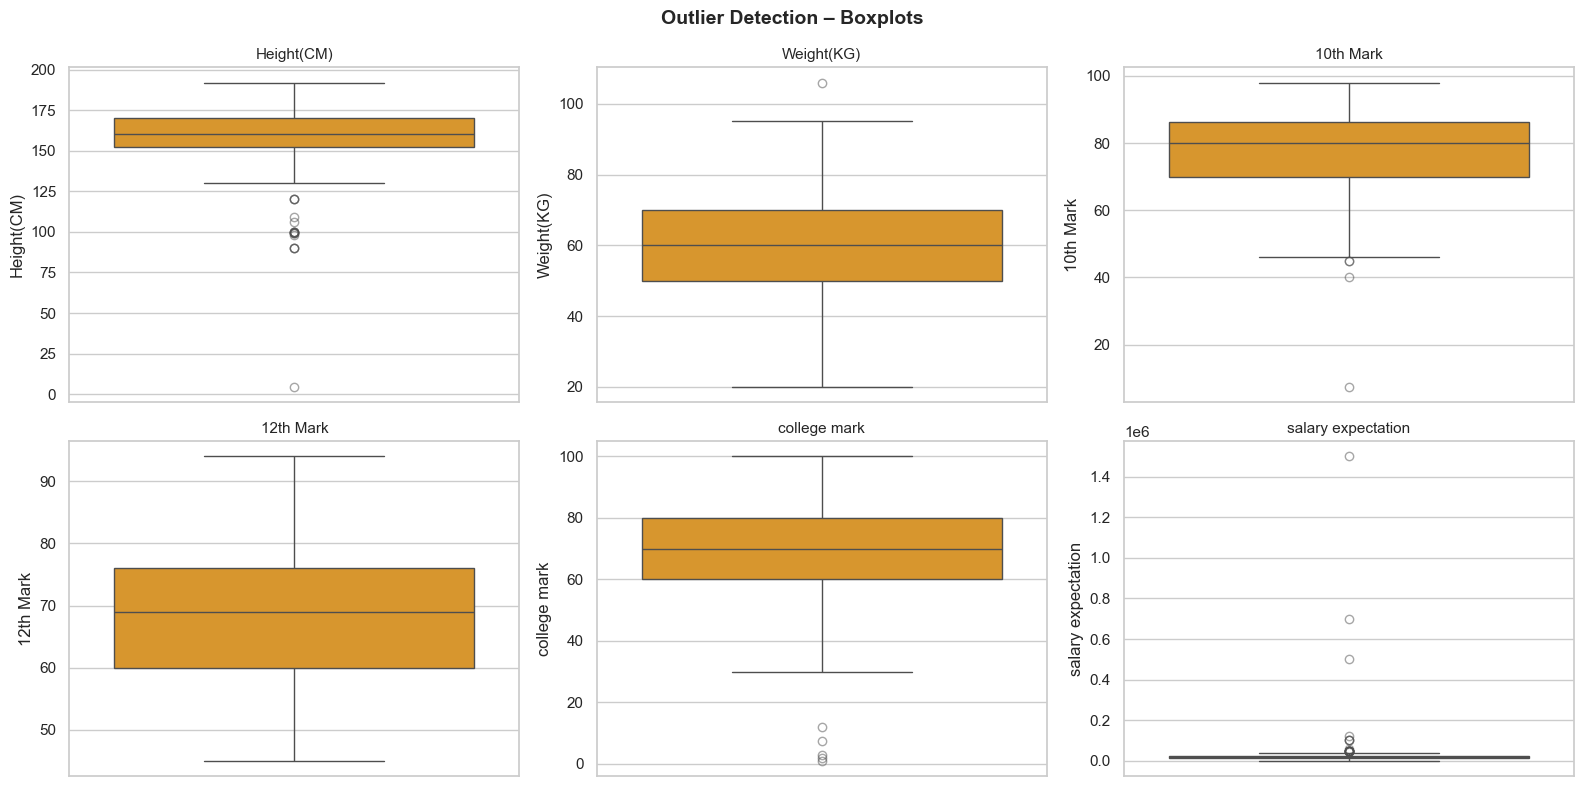

,Column,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier %
0,salary expectation,15000.0,25000.00,10000.00,0.000,40000.000,19,8.09
1,Height(CM),152.0,170.00,18.00,125.000,197.000,17,7.23
2,college mark,60.0,80.00,20.00,30.000,110.000,5,2.13
3,10th Mark,70.0,86.25,16.25,45.625,110.625,4,1.70
4,Weight(KG),50.0,70.00,20.00,20.000,100.000,1,0.43
5,12th Mark,60.0,76.00,16.00,36.000,100.000,0,0.00


In [12]:
# ── Cell 12: Outlier Detection – Boxplots + IQR Summary ──────────────────────
num_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=num_df[col].dropna(), ax=axes[i], color="#F39C12", flierprops=dict(marker="o", color="red", alpha=0.5))
    axes[i].set_title(col, fontsize=11)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Outlier Detection – Boxplots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# IQR outlier summary table
records = []
for col in numeric_cols:
    s = num_df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    records.append({"Column": col, "Q1": q1, "Q3": q3, "IQR": iqr,
                    "Lower Fence": q1 - 1.5*iqr, "Upper Fence": q3 + 1.5*iqr,
                    "Outlier Count": n_out, "Outlier %": round(n_out/len(s)*100, 2)})

display(pd.DataFrame(records).sort_values("Outlier %", ascending=False).reset_index(drop=True))

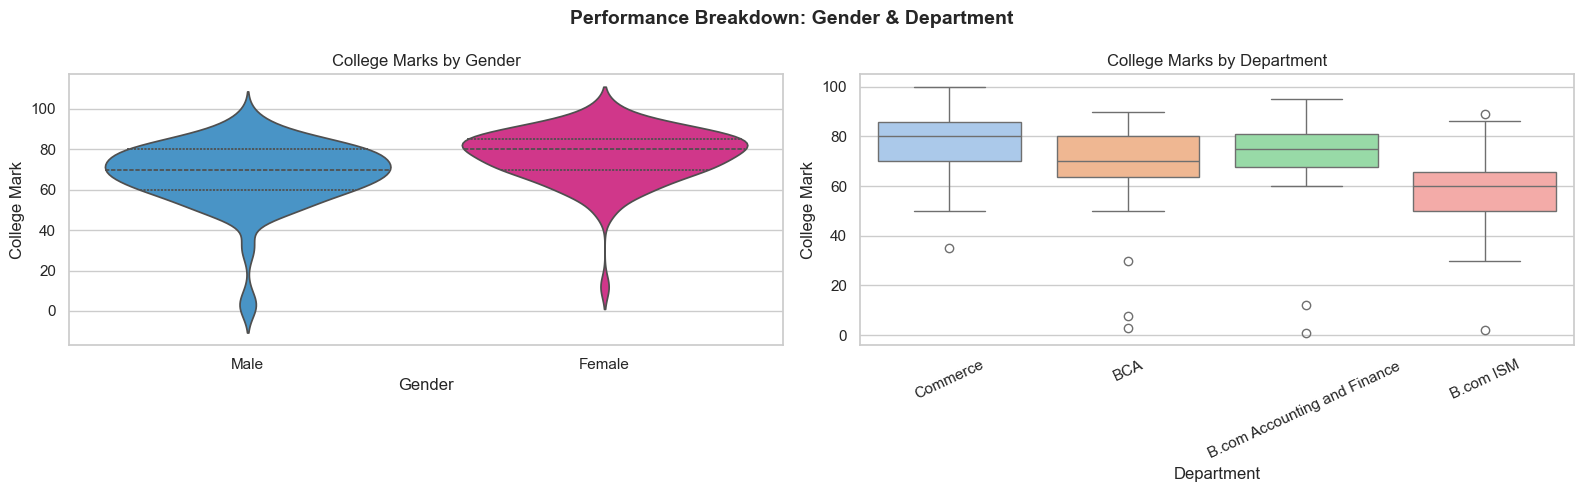


Mean college marks by gender:


,mean,median,count
Gender,,,
Female,76.87,80.0,79
Male,67.52,70.0,156



Mean college marks by department:


,mean,median,count
Department,,,
B.com Accounting and Finance,67.93,75.0,15
B.com ISM,59.29,60.0,28
BCA,69.92,70.0,132
Commerce,78.28,80.0,60


In [13]:
# ── Cell 13: Gender & Department – Performance Breakdown ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gender vs College Marks
sns.violinplot(data=df, x="Gender", y="college mark_num",
               palette={"Male": "#3498db", "Female": "#e91e8c"}, inner="quartile", ax=axes[0])
axes[0].set_title("College Marks by Gender", fontsize=12)
axes[0].set_ylabel("College Mark")

# Department vs College Marks
dept_order = df.groupby("Department")["college mark_num"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="Department", y="college mark_num",
            order=dept_order, palette="pastel", ax=axes[1])
axes[1].set_title("College Marks by Department", fontsize=12)
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_ylabel("College Mark")

plt.suptitle("Performance Breakdown: Gender & Department", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nMean college marks by gender:")
display(df.groupby("Gender")["college mark_num"].agg(["mean","median","count"]).round(2))
print("\nMean college marks by department:")
display(df.groupby("Department")["college mark_num"].agg(["mean","median","count"]).round(2))

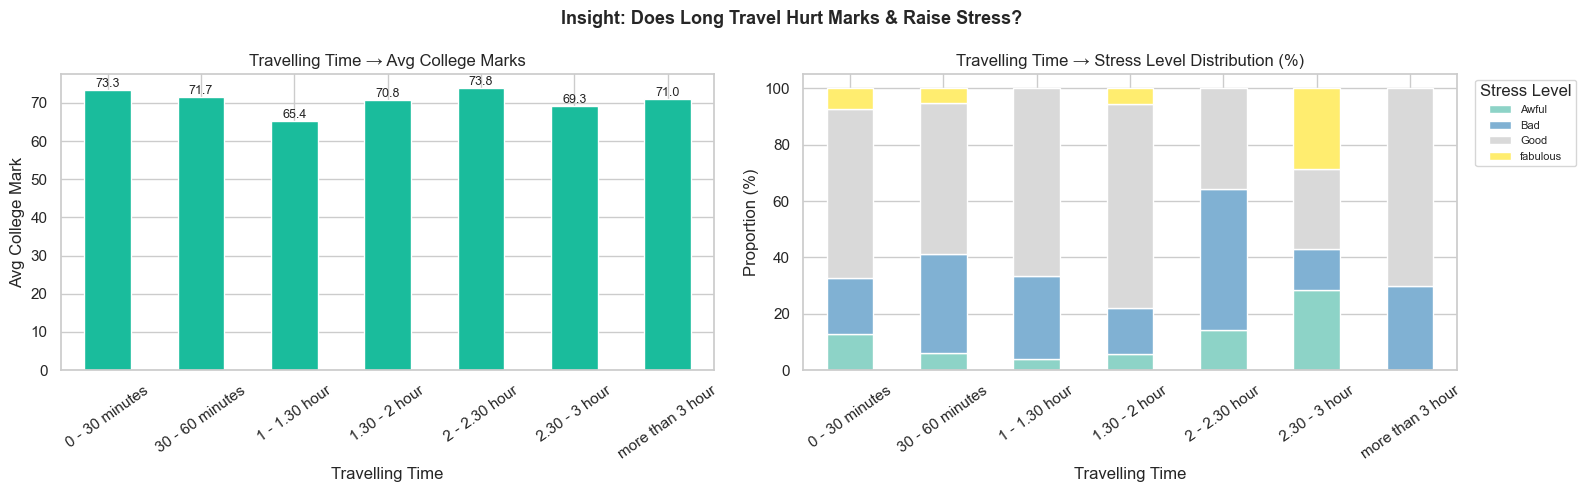

In [14]:
# ── Cell 14: Travelling Time vs Marks & Stress ───────────────────────────────
travel_order = ["0 - 30 minutes", "30 - 60 minutes",
                "1 - 1.30 hour", "1.30 - 2 hour",
                "2 - 2.30 hour", "2.30 - 3 hour", "more than 3 hour"]
travel_col = "Travelling Time"
travel_order = [t for t in travel_order if t in df[travel_col].values]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Travel time vs marks
avg_t = df.groupby(travel_col)["college mark_num"].mean().reindex(travel_order)
avg_t.plot(kind="bar", color="#1abc9c", edgecolor="white", ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)
axes[0].set_title("Travelling Time → Avg College Marks", fontsize=12)
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_xlabel("Travelling Time")
axes[0].set_ylabel("Avg College Mark")

# Travel time vs stress distribution (stacked count %)
cross = pd.crosstab(df[travel_col], df["Stress Level"], normalize="index") * 100
cross = cross.reindex(travel_order)
cross.plot(kind="bar", stacked=True, colormap="Set3", edgecolor="white", ax=axes[1])
axes[1].set_title("Travelling Time → Stress Level Distribution (%)", fontsize=12)
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_xlabel("Travelling Time")
axes[1].set_ylabel("Proportion (%)")
axes[1].legend(title="Stress Level", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.suptitle("Insight: Does Long Travel Hurt Marks & Raise Stress?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Numeric feature means by performer segment:


,Height(CM),Weight(KG),10th Mark,12th Mark,college mark,salary expectation
performer,,,,,,
High Performer,156.68,60.52,81.54,72.44,79.22,21937.88
Low Performer,158.72,61.33,68.25,62.07,54.99,51790.81


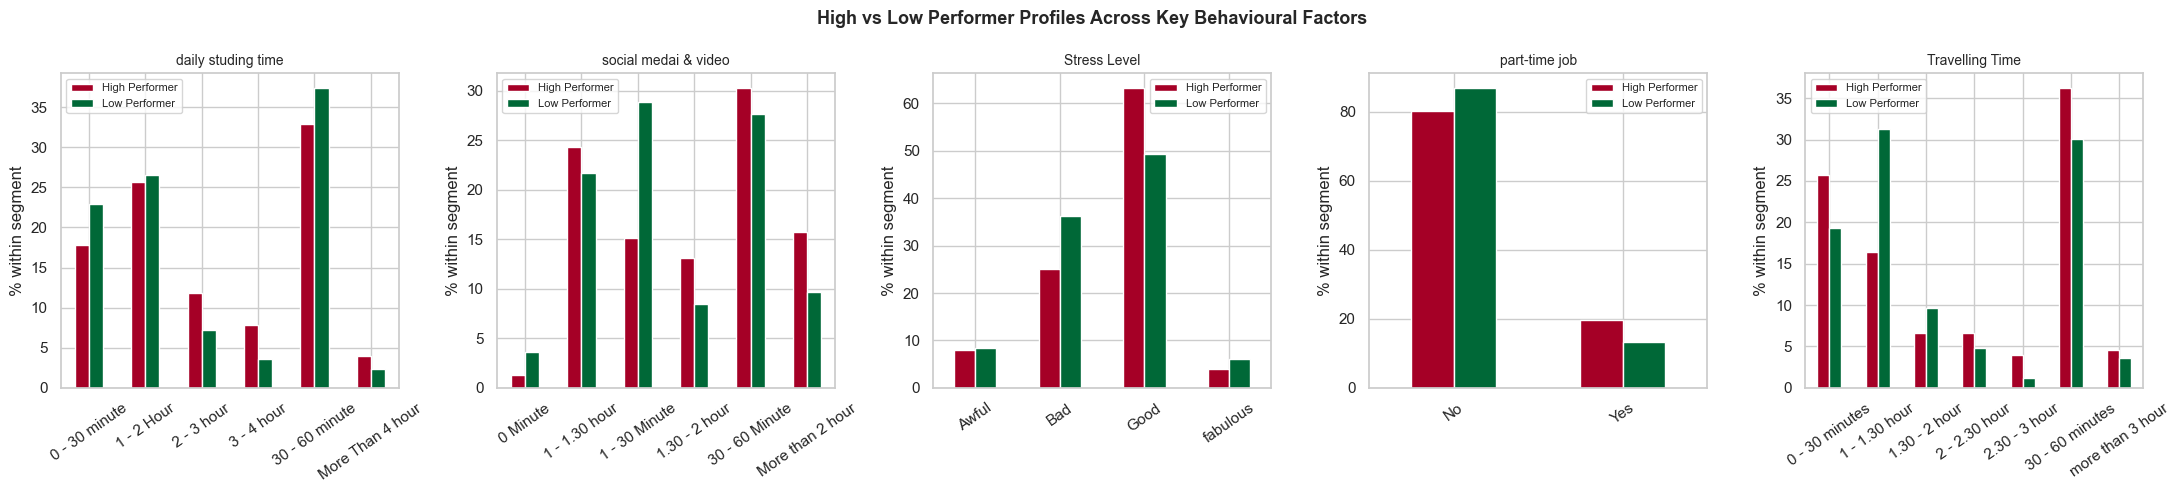

In [16]:
# ── Cell 15: Segment Profile – High vs Low Performers ────────────────────────
seg = df.copy()
seg["college mark_num"] = pd.to_numeric(seg["college mark"], errors="coerce")
median_mark = seg["college mark_num"].median()
seg["performer"] = np.where(seg["college mark_num"] >= median_mark, "High Performer", "Low Performer")

# Numeric averages per segment
profile_num = seg.groupby("performer")[numeric_cols].apply(
    lambda g: g.apply(pd.to_numeric, errors="coerce").mean()
).round(2)
print("Numeric feature means by performer segment:")
display(profile_num)

# Categorical distributions per segment
cat_profile_cols = ["daily studing time", "social medai & video", "Stress Level",
                    "part-time job", "Travelling Time"]

fig, axes = plt.subplots(1, len(cat_profile_cols), figsize=(22, 5))

for ax, col in zip(axes, cat_profile_cols):
    cross = pd.crosstab(seg[col], seg["performer"], normalize="columns") * 100
    cross.plot(kind="bar", ax=ax, colormap="RdYlGn", edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    ax.set_ylabel("% within segment")
    ax.legend(fontsize=8)

plt.suptitle("High vs Low Performer Profiles Across Key Behavioural Factors",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()